Comprobar que usamos la GPU de Google Colab


In [ ]:
!nvidia-smi

Sat May  3 14:13:17 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   64C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Librería de ultralytics para usar YOLO

In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
import os
import time
import zipfile
from huggingface_hub import snapshot_download

In [ ]:
# Repositorio con los códigos del proyecto
!git clone https://github.com/AleNunezArroyo/spacecraft-detection.git
%cd 'spacecraft-detection'
!pwd

Cloning into 'spacecraft-detection'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 4), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 29.09 MiB | 17.26 MiB/s, done.
Resolving deltas: 100% (4/4), done.
/content/spacecraft-detection
/content/spacecraft-detection


In [ ]:
PATH = os.getcwd()
dataset_folder = PATH + '/spacecraft-dataset'

In [ ]:
os.makedirs(dataset_folder, exist_ok=True)

In [ ]:
# Dataset en HuggingFace
snapshot_download(
    repo_id="AleNunezArroyo/spacecraft-dataset",
    repo_type="dataset",
    local_dir=dataset_folder,
    token=None
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

train.zip:   0%|          | 0.00/1.97G [00:00<?, ?B/s]

val.zip:   0%|          | 0.00/432M [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/2.46k [00:00<?, ?B/s]

test.zip:   0%|          | 0.00/147M [00:00<?, ?B/s]

README.md:   0%|          | 0.00/102 [00:00<?, ?B/s]

all_bbox.txt:   0%|          | 0.00/129k [00:00<?, ?B/s]

'/content/spacecraft-detection/spacecraft-dataset'

In [ ]:
import os
def unzip(zip_name):
    zip_path = os.path.join(dataset_folder, zip_name + ".zip")

    # Extraer directamente en el folder del dataset
    if not os.path.exists(os.path.join(dataset_folder, zip_name)):
        print(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dataset_folder)
        print(f"Extracted to {dataset_folder}")
    else:
        print(f"{os.path.join(dataset_folder, zip_name)} already exists. Skipping.")

for split in ["test", "train", "val"]:
    unzip(split)

Extracting /content/spacecraft-detection/spacecraft-dataset/test.zip...
Extracted to /content/spacecraft-detection/spacecraft-dataset
Extracting /content/spacecraft-detection/spacecraft-dataset/train.zip...
Extracted to /content/spacecraft-detection/spacecraft-dataset
Extracting /content/spacecraft-detection/spacecraft-dataset/val.zip...
Extracted to /content/spacecraft-detection/spacecraft-dataset


In [ ]:
dataset_folder

'/content/spacecraft-detection/spacecraft-dataset'

In [ ]:
os.makedirs(dataset_folder+'/images', exist_ok=True)

In [ ]:
!mv {dataset_folder}'/val' {dataset_folder}'/images'
!mv {dataset_folder}'/test' {dataset_folder}'/images'
!mv {dataset_folder}'/train' {dataset_folder}'/images'

Opcional

In [ ]:
# files_to_remove = ["train.zip", "test.zip", "val.zip"]
# for file in files_to_remove:
#     path = os.path.join(dataset_folder, file)
#     if os.path.exists(path):
#         os.remove(path)

In [ ]:
!python3 yolo_transformer.py

Archivos YOLO generados


# Setup

In [ ]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.124 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 46.1/112.6 GB disk)


# 1. Predict

YOLO11 puede usarse directamente desde la interfaz de línea de comandos (CLI) con el comando yolo para una variedad de tareas y modos, y acepta argumentos adicionales, por ejemplo: imgsz=640. Consulta la lista completa de [argumentos](https://docs.ultralytics.com/usage/cfg/) disponibles para yolo y otros detalles en la documentación de predicción de [YOLO11 Predict Docs](https://docs.ultralytics.com/modes/train/).

In [ ]:
start = time.time()
!yolo predict model=yolo11n.pt source='spacecraft-dataset/images/test/img_resize_403.png' device=cpu project='resultados' name='sin_entrenamiento' exist_ok=True
end = time.time()
print(f"Tiempo de ejecución CPU: {end - start:.4f} segundos")

Ultralytics 8.3.124 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_403.png: 384x640 1 boat, 109.2ms
Speed: 2.6ms preprocess, 109.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)
Results saved to resultados/sin_entrenamiento
💡 Learn more at https://docs.ultralytics.com/modes/predict
Tiempo de ejecución CPU: 5.7181 segundos


In [ ]:
start = time.time()
!yolo predict model=yolo11n.pt source='spacecraft-dataset/images/test/img_resize_403.png' device=cuda:0 project='resultados' name='sin_entrenamiento' exist_ok=True
end = time.time()
print(f"Tiempo de ejecución GPU: {end - start:.4f} segundos")

Ultralytics 8.3.124 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_403.png: 384x640 1 boat, 66.9ms
Speed: 2.1ms preprocess, 66.9ms inference, 309.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to resultados/sin_entrenamiento
💡 Learn more at https://docs.ultralytics.com/modes/predict
Tiempo de ejecución GPU: 6.6263 segundos


# 2. Val

Realizaremos la inferencia sobre el conjunto `test` únicamente con el objetivo de evaluar el rendimiento del modelo `yolo11n.pt`, el cual no ha sido entrenado específicamente para esta tarea. Además, compararemos el desempeño entre ejecuciones en CPU y GPU.

In [ ]:
start = time.time()
!yolo predict model=yolo11n.pt source="spacecraft-dataset/images/test" device=cpu project='resultados' name='sin_entrenamiento' exist_ok=True
end = time.time()
t_cpu = end - start
print(f"Tiempo de ejecución CPU: {t_cpu:.4f} segundos")

Ultralytics 8.3.124 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.00GHz)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_1000.png: 384x640 (no detections), 104.2ms
image 2/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_403.png: 384x640 1 boat, 92.4ms
image 3/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_405.png: 384x640 1 kite, 78.4ms
image 4/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_412.png: 384x640 1 airplane, 86.4ms
image 5/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_415.png: 384x640 (no detections), 86.2ms
image 6/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_419.png: 384x640 1 boat, 1 umbrella, 80.5ms
image 7/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_423.png: 384x640 (no

In [ ]:
start = time.time()
!yolo detect predict model=yolo11n.pt source="spacecraft-dataset/images/test" device=cuda:0 project='resultados' name='sin_entrenamiento' exist_ok=True
end = time.time()
t_gpu = end - start
print(f"Tiempo de ejecución GPU: {t_gpu:.4f} segundos")

Ultralytics 8.3.124 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_1000.png: 384x640 (no detections), 44.8ms
image 2/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_403.png: 384x640 1 boat, 8.8ms
image 3/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_405.png: 384x640 1 kite, 11.2ms
image 4/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_412.png: 384x640 1 airplane, 8.6ms
image 5/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_415.png: 384x640 (no detections), 9.5ms
image 6/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_419.png: 384x640 1 boat, 1 umbrella, 14.4ms
image 7/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_423.png: 384x640 (no 

La inferencia en GPU es mucho más rápida que la inferencia en CPU.

In [ ]:
print(t_cpu, t_gpu)

22.51406502723694 11.154610633850098


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
def mostrar_imagenes(path_base, ids_imagenes, filas=2, columnas=4):
    imagenes = []
    titulos = []

    for i in ids_imagenes:
        path = os.path.join(path_base, f'img_resize_{i}.jpg')
        imagen = cv2.imread(path)
        if imagen is None:
            print(f'No se pudo cargar la imagen: {path}')
            continue
        imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        imagenes.append(imagen_rgb)
        titulos.append(f'Imagen {i}')

    fig, axs = plt.subplots(filas, columnas, figsize=(20, 8))
    axs = axs.flatten()

    for idx, (img, title) in enumerate(zip(imagenes, titulos)):
        axs[idx].imshow(img)
        axs[idx].set_title(title)
        axs[idx].axis('off')

    for j in range(len(imagenes), len(axs)):  # Oculta ejes vacíos si sobran
        axs[j].axis('off')
    plt.subplots_adjust(wspace=0, hspace=-0.5)
    plt.tight_layout(pad=0)
    plt.show()

In [ ]:
f'{PATH}/resultados/sin_entrenamiento'

'/content/spacecraft-detection/resultados/sin_entrenamiento'

Visualización de las inferencias del peso base sin entrenamiento.

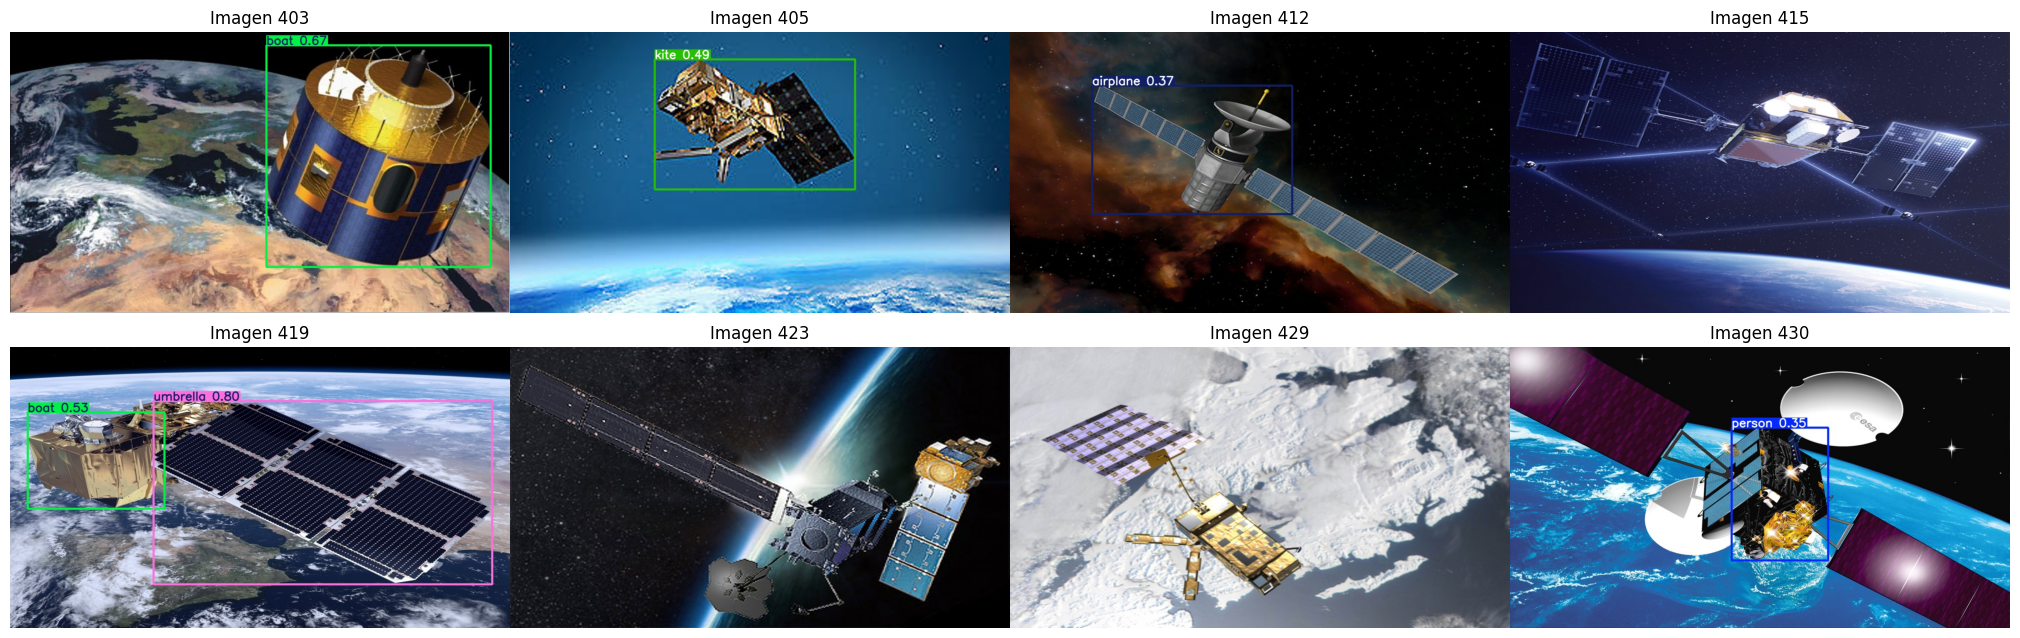

In [ ]:
sin_entrenamiento = f'{PATH}/resultados/sin_entrenamiento'
ids = [403, 405, 412, 415, 419, 423, 429, 430]
mostrar_imagenes(sin_entrenamiento, ids)

Crearemos el archivo space.yaml, importante para apuntar correctamente a nuestros datos de entrenamiento y validación.


In [ ]:
import yaml
from pathlib import Path

# Ruta donde quieres guardar el archivo
output_path = PATH + '/space.yaml'

# Estructura del archivo
data = {
    "train": f'{dataset_folder}/images/train',
    "val": f'{dataset_folder}/images/val',
    "test": f'{dataset_folder}/images/test',
    "names": {
        0: "spacecraft"
    }
}

# Escribir archivo YAML
with open(output_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print(f"Archivo generado en: {output_path}")

Archivo generado en: /content/spacecraft-detection/space.yaml


# 3. Train

Entrenamiento del modelo

In [ ]:
!cat /content/spacecraft-detection/spacecraft-dataset/labels/val/*.txt | wc -l

552


In [ ]:
!yolo train model=yolo11n.pt data=space.yaml epochs=15 imgsz=640 device=cuda:0 batch=0.90 cache=True patience=20

Ultralytics 8.3.124 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=space.yaml, epochs=15, time=None, patience=20, batch=0.9, imgsz=640, save=True, save_period=-1, cache=True, device=cuda:0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None, format=to

In [ ]:
!zip -r train15.zip /content/spacecraft-detection/runs/detect/train

  adding: content/spacecraft-detection/runs/detect/train/ (stored 0%)
  adding: content/spacecraft-detection/runs/detect/train/train_batch157.jpg (deflated 24%)
  adding: content/spacecraft-detection/runs/detect/train/R_curve.png (deflated 16%)
  adding: content/spacecraft-detection/runs/detect/train/val_batch0_pred.jpg (deflated 9%)
  adding: content/spacecraft-detection/runs/detect/train/labels_correlogram.jpg (deflated 33%)
  adding: content/spacecraft-detection/runs/detect/train/results.png (deflated 7%)
  adding: content/spacecraft-detection/runs/detect/train/confusion_matrix_normalized.png (deflated 36%)
  adding: content/spacecraft-detection/runs/detect/train/confusion_matrix.png (deflated 36%)
  adding: content/spacecraft-detection/runs/detect/train/val_batch2_pred.jpg (deflated 9%)
  adding: content/spacecraft-detection/runs/detect/train/weights/ (stored 0%)
  adding: content/spacecraft-detection/runs/detect/train/weights/best.pt (deflated 10%)
  adding: content/spacecraft-det

In [ ]:
start = time.time()
!yolo detect predict model="/content/spacecraft-detection/runs/detect/train/weights/best.pt" source="spacecraft-dataset/images/test" device=cuda:0 project='resultados' name='con_entrenamiento' exist_ok=True
end = time.time()
print(f"Tiempo de ejecución GPU: {end - start:.4f} segundos")

Ultralytics 8.3.124 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs

image 1/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_1000.png: 384x640 1 spacecraft, 46.6ms
image 2/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_403.png: 384x640 1 spacecraft, 8.8ms
image 3/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_405.png: 384x640 1 spacecraft, 8.3ms
image 4/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_412.png: 384x640 1 spacecraft, 8.1ms
image 5/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_415.png: 384x640 1 spacecraft, 8.0ms
image 6/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_419.png: 384x640 1 spacecraft, 8.1ms
image 7/156 /content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_423.png: 384x640 1 sp

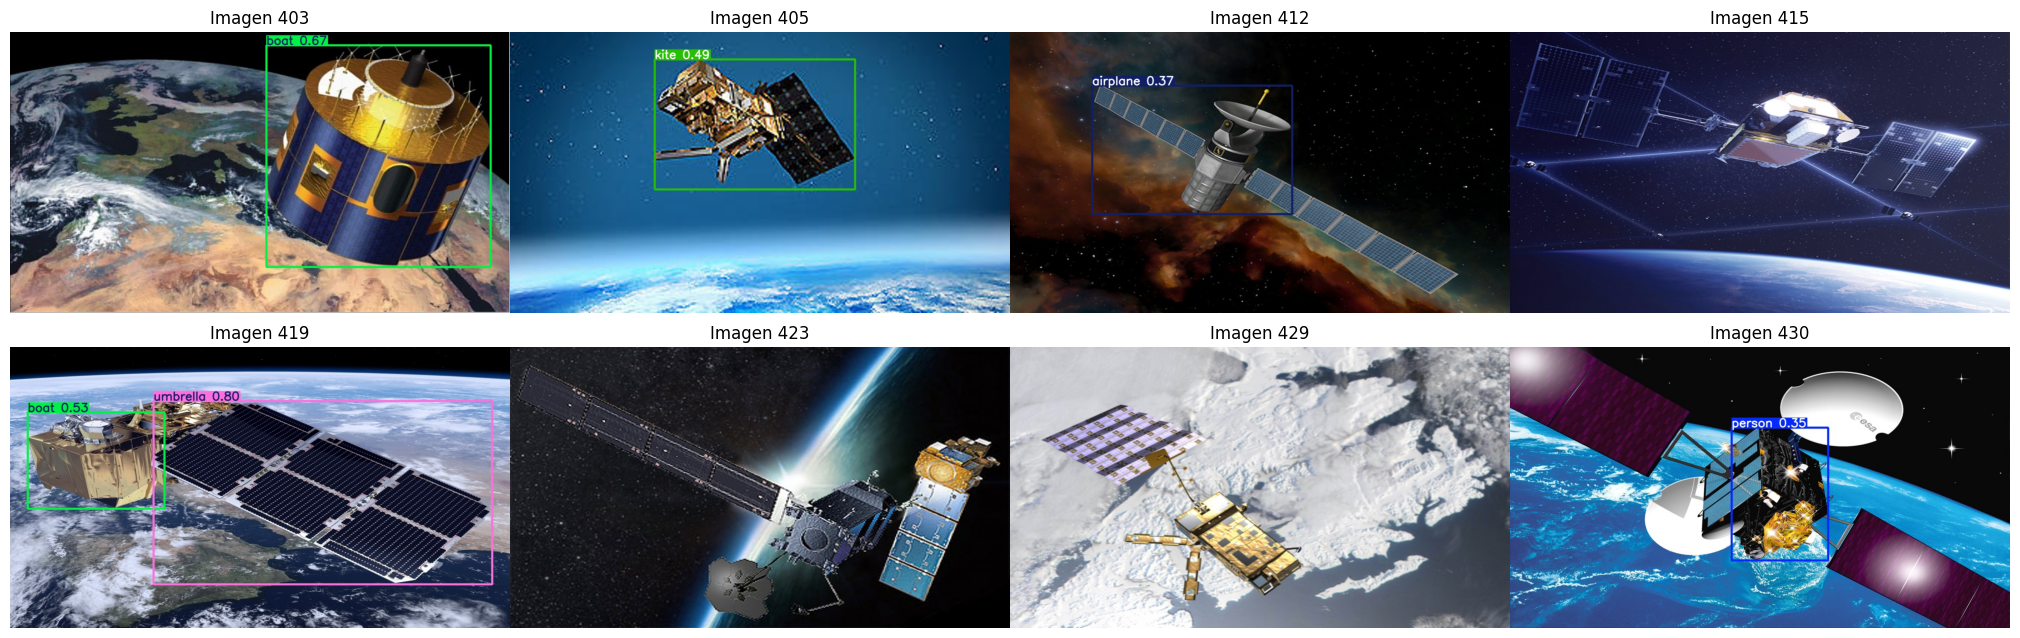

In [ ]:
sin_entrenamiento = f'{PATH}/resultados/sin_entrenamiento'
ids = [403, 405, 412, 415, 419, 423, 429, 430]
mostrar_imagenes(sin_entrenamiento, ids)

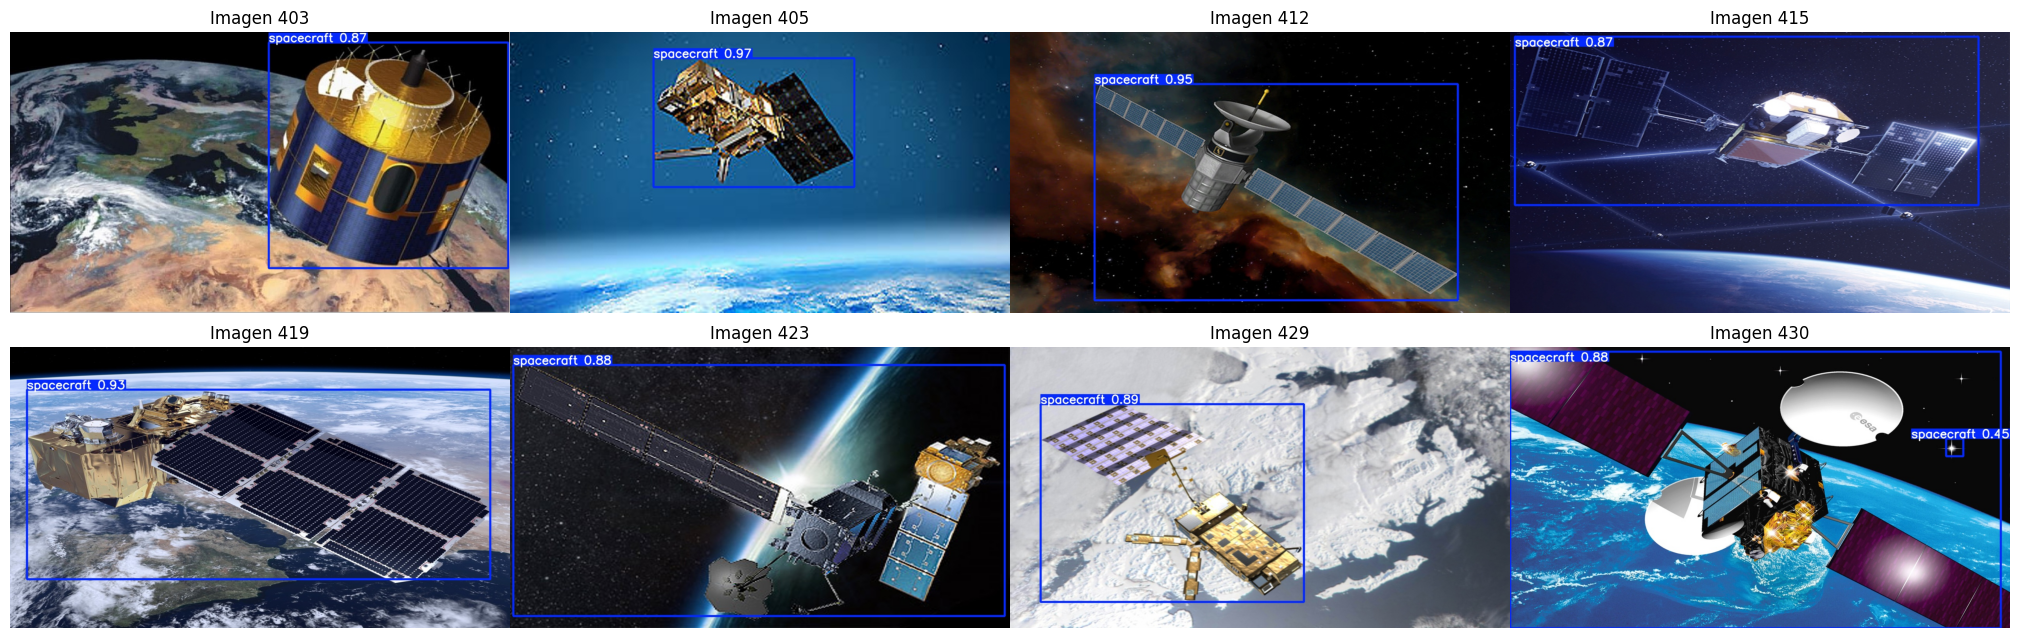

In [ ]:
con_entrenamiento = f'{PATH}/resultados/con_entrenamiento'
ids = [403, 405, 412, 415, 419, 423, 429, 430]
mostrar_imagenes(con_entrenamiento, ids)

# 5. Python Usage

In [ ]:
!git clone https://github.com/AleNunezArroyo/spacecraft-detection.git

Cloning into 'spacecraft-detection'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 18 (delta 4), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 29.09 MiB | 25.85 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
%pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 853.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
!unzip /content/spacecraft-detection/yolo_50-100_epochs.zip -d /content/spacecraft-detection/

Archive:  /content/spacecraft-detection/yolo_50-100_epochs.zip
   creating: /content/spacecraft-detection/yolo_50-100_epochs/
   creating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/args.yaml  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/confusion_matrix.png  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/confusion_matrix_normalized.png  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/F1_curve.png  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/labels.jpg  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/labels_correlogram.jpg  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/PR_curve.png  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100_epochs/P_curve.png  
  inflating: /content/spacecraft-detection/yolo_50-100_epochs/100

Esto reemplazar con la ruta del peso que queremos usar en Python.
`/content/spacecraft-detection/runs/detect/train/weights/best.pt`

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO('/content/spacecraft-detection/runs/detect/train/weights/best.pt')


0: 384x640 1 spacecraft, 15.6ms
Speed: 3.5ms preprocess, 15.6ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


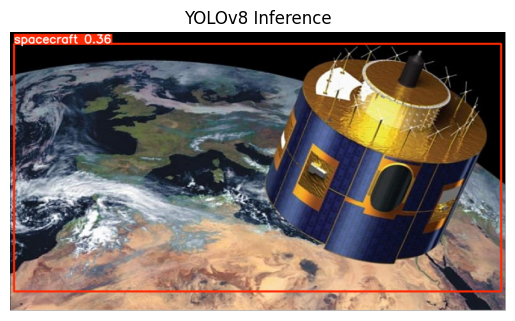

Clases detectadas: tensor([0.], device='cuda:0')
Confianzas: tensor([0.3638], device='cuda:0')


In [ ]:
image_path = '/content/spacecraft-detection/spacecraft-dataset/images/test/img_resize_403.png'
imagen = cv2.imread(image_path)
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
results = model(imagen_rgb)

# Mostrar resultados con Matplotlib
for r in results:
    im_array = r.plot()
    plt.imshow(im_array)
    plt.axis('off')
    plt.title("YOLOv11 Inference")
    plt.show()

for r in results:
    boxes = r.boxes
    confs = r.boxes.conf
    classes = r.boxes.cls
    print(f"Clases detectadas: {classes}")
    print(f"Confianzas: {confs}")

# Extra

In [ ]:
width, height = 1280, 720
bbox = [1003, 549, 114, 152]
max_x, max_y, min_x, min_y = bbox
x = min_x
y = min_y
w = max_x - min_x
h = max_y - min_y

x_center = (x + w / 2) / width
y_center = (y + h / 2) / height
w_norm = w / width
h_norm = h / height

print(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")